# Tadabur Dataset — Exploratory Data Analysis
**CS465 Machine Learning Project**

This notebook performs EDA on the Tadabur Quranic ASR dataset.
All figures generated here will be used directly in the IEEE paper.

## 1. Install Dependencies

In [1]:
!pip install datasets huggingface_hub matplotlib seaborn pandas numpy librosa soundfile IPython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 269.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 272.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 281.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 209.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 205.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 228.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 212.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 190.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 230.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pyparsing
   

In [2]:
!pip install pyarrow --upgrade


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
%pip install fastparquet


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
%pip install pyarrow


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install glob2


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


## 2. Login to HuggingFace
Paste your token from **huggingface.co → Settings → Access Tokens**

In [ ]:
from huggingface_hub import login

login(token="")  # <- paste your token here (READ permissions)

R:\CS465-ML-Project\tadabur-asr\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Load Dataset (Streaming — No Download Needed)

In [3]:
import pandas as pd
from glob import glob

files = sorted(glob("/workspace/tadabur/data/*.parquet"))

flat_cols = [
    "reciter_id",
    "surah_id",
    "ayah_id",
    "text_ar_simple",
    "text_ar_uthmani",
    "ayah_duration_s",
    "metadata",
]

df = pd.concat(
    [pd.read_parquet(f, columns=flat_cols) for f in files],
    ignore_index=True
)



In [7]:
df.describe()

,reciter_id,surah_id,ayah_id,ayah_duration_s
count,409139.000000,409139.000000,409139.000000,409139.000000
mean,164.891159,31.240867,57.759485,13.511454
std,190.988228,26.939148,54.486097,9.599786
min,0.000000,1.000000,1.000000,-3.670000
25%,38.000000,10.000000,17.000000,6.785000
50%,80.000000,24.000000,41.000000,11.052000
75%,197.000000,44.000000,81.000000,17.356001
max,743.000000,113.000000,286.000000,182.186005


## 4. Inspect a Single Sample

In [10]:
sample = df.iloc[0].to_dict()

print("=== Sample Keys ===")
for key in sample.keys():
    print(f"  {key}: {type(sample[key])}")

print("\n=== Sample Values ===")
print(f"  Reciter ID  : {sample['reciter_id']}")
print(f"  Surah ID    : {sample['surah_id']}")
print(f"  Ayah ID     : {sample['ayah_id']}")
print(f"  Duration (s): {sample['ayah_duration_s']}")
print(f"  Arabic text : {sample['text_ar_uthmani'][:80]}...")
print(f"  Metadata    : {sample['metadata']}")

=== Sample Keys ===
  reciter_id: <class 'int'>
  surah_id: <class 'int'>
  ayah_id: <class 'int'>
  text_ar_simple: <class 'str'>
  text_ar_uthmani: <class 'str'>
  ayah_duration_s: <class 'float'>
  metadata: <class 'str'>

=== Sample Values ===
  Reciter ID  : 79
  Surah ID    : 16
  Ayah ID     : 88
  Duration (s): 19.503999710083008
  Arabic text : قُل لَّئِنِ ٱجْتَمَعَتِ ٱلْإِنسُ وَٱلْجِنُّ عَلَىٰٓ أَن يَأْتُوا۟ بِمِثْلِ هَـٰذ...
  Metadata    : {"reciter_id": 79, "surah_id": 16, "ayah_id": 88, "word_alignments": [{"word": "قل", "start": 0.0, "end": 0.681}, {"word": "لئن", "start": 0.501, "end": 1.101}, {"word": "اجتمعت", "start": 0.921, "end": 2.243}, {"word": "الانس", "start": 2.083, "end": 3.744}, {"word": "والجن", "start": 3.605, "end": 5.226}, {"word": "على", "start": 5.226, "end": 6.007}, {"word": "ان", "start": 5.907, "end": 6.788}, {"word": "ياتوا", "start": 6.668, "end": 7.729}, {"word": "بمثل", "start": 7.609, "end": 8.57}, {"word": "هذا", "start": 8.49, "end": 9.271}, 

## 5. Collect Statistics (Sample 5000 Records)
We stream and collect metadata from 5000 samples for EDA.
This avoids downloading the full 1TB dataset.

In [12]:
import pandas as pd
import json

SAMPLE_SIZE = 5000

records = []
for i, (_, sample) in enumerate(df.iterrows()):
    meta = json.loads(sample["metadata"])

    records.append({
        "reciter_id": sample["reciter_id"],
        "surah_id": sample["surah_id"],
        "ayah_id": sample["ayah_id"],
        "duration_s": sample["ayah_duration_s"],
        "text_simple": sample["text_ar_simple"],
        "word_count": len(sample["text_ar_simple"].split()),
        "num_alignments": len(meta["word_alignments"]),
        "audio_filename": meta["audio_filename"],
    })

    if (i + 1) % 100 == 0:
        print(f"Collected {i+1}/{SAMPLE_SIZE} samples...")

    if i + 1 >= SAMPLE_SIZE:
        break

result_df = pd.DataFrame(records)
print(f"\nDataFrame shape: {result_df.shape}")
result_df.head()

Collected 100/5000 samples...
Collected 200/5000 samples...
Collected 300/5000 samples...
Collected 400/5000 samples...
Collected 500/5000 samples...
Collected 600/5000 samples...
Collected 700/5000 samples...
Collected 800/5000 samples...
Collected 900/5000 samples...
Collected 1000/5000 samples...
Collected 1100/5000 samples...
Collected 1200/5000 samples...
Collected 1300/5000 samples...
Collected 1400/5000 samples...
Collected 1500/5000 samples...
Collected 1600/5000 samples...
Collected 1700/5000 samples...
Collected 1800/5000 samples...
Collected 1900/5000 samples...
Collected 2000/5000 samples...
Collected 2100/5000 samples...
Collected 2200/5000 samples...
Collected 2300/5000 samples...
Collected 2400/5000 samples...
Collected 2500/5000 samples...
Collected 2600/5000 samples...
Collected 2700/5000 samples...
Collected 2800/5000 samples...
Collected 2900/5000 samples...
Collected 3000/5000 samples...
Collected 3100/5000 samples...
Collected 3200/5000 samples...
Collected 3300/50

,reciter_id,surah_id,ayah_id,duration_s,text_simple,word_count,num_alignments,audio_filename
0,79,16,88,19.504000,قل لئن اجتمعت الانس والجن على ان ياتوا بمثل هذ...,19,19,tadabur_spk0079_S16_A88_b85c70aa_000079.wav
1,65,33,28,19.516001,وما ارسلناك الا كافة للناس بشيرا ونذيرا ولكن ا...,12,12,tadabur_spk0065_S33_A28_ef5369a9_000002.wav
2,52,69,13,3.181000,وفصيلته التي تؤويه,3,3,tadabur_spk0052_S69_A13_e9504088_000130.wav
3,282,35,30,15.157000,يا حسرة على العباد ما ياتيهم من رسول الا كانوا...,12,12,tadabur_spk0282_S35_A30_f0a057c0_000000.wav
4,192,1,241,7.709000,وللمطلقات متاع بالمعروف حقا على المتقين,6,6,tadabur_spk0192_S1_A241_2f737953_000238.wav


## 6. Basic Statistical Summary

In [14]:
print("=== Dataset Summary ===")
print(f"Total samples collected      : {len(df)}")
print(f"Unique reciters              : {df['reciter_id'].nunique()}")
print(f"Unique surahs                : {df['surah_id'].nunique()}")
print(f"Unique ayahs                 : {df['ayah_id'].nunique()}")
print(f"Avg audio duration           : {df['ayah_duration_s'].mean():.2f}s")
print(f"Min / Max duration           : {df['ayah_duration_s'].min():.2f}s / {df['ayah_duration_s'].max():.2f}s")
print(f"Sampling rate                : 16,000 Hz (Whisper-compatible)")
print()
print(df[["ayah_duration_s"]].describe())

=== Dataset Summary ===
Total samples collected      : 409139
Unique reciters              : 671
Unique surahs                : 113
Unique ayahs                 : 285
Avg audio duration           : 13.51s
Min / Max duration           : -3.67s / 182.19s
Sampling rate                : 16,000 Hz (Whisper-compatible)

       ayah_duration_s
count    409139.000000
mean         13.511454
std           9.599786
min          -3.670000
25%           6.785000
50%          11.052000
75%          17.356001
max         182.186005


## 7. Visualizations
All figures are saved to `figures/` for use in the IEEE paper.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.2)
SAVE = lambda name: plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")

### 7.1 Audio Duration Distribution

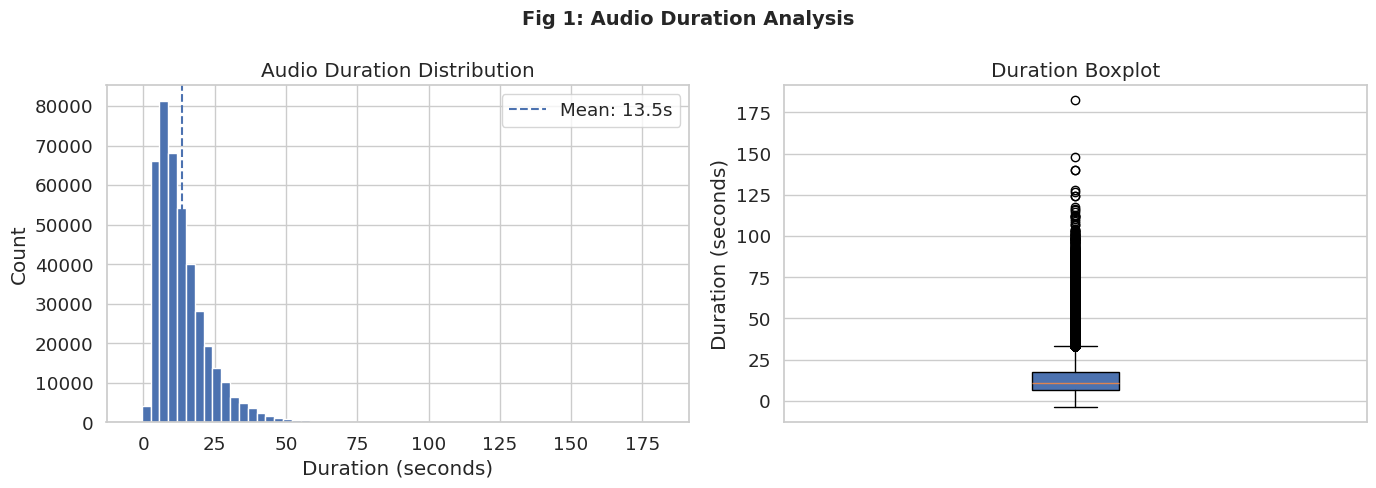

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["ayah_duration_s"], bins=60, edgecolor="white")
axes[0].axvline(
    df["ayah_duration_s"].mean(),
    linestyle="--",
    label=f'Mean: {df["ayah_duration_s"].mean():.1f}s'
)
axes[0].set_title("Audio Duration Distribution")
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot
axes[1].boxplot(df["ayah_duration_s"], vert=True, patch_artist=True)
axes[1].set_title("Duration Boxplot")
axes[1].set_ylabel("Duration (seconds)")
axes[1].set_xticks([])

plt.suptitle("Fig 1: Audio Duration Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 7.2 Reciter Distribution (Top 30)

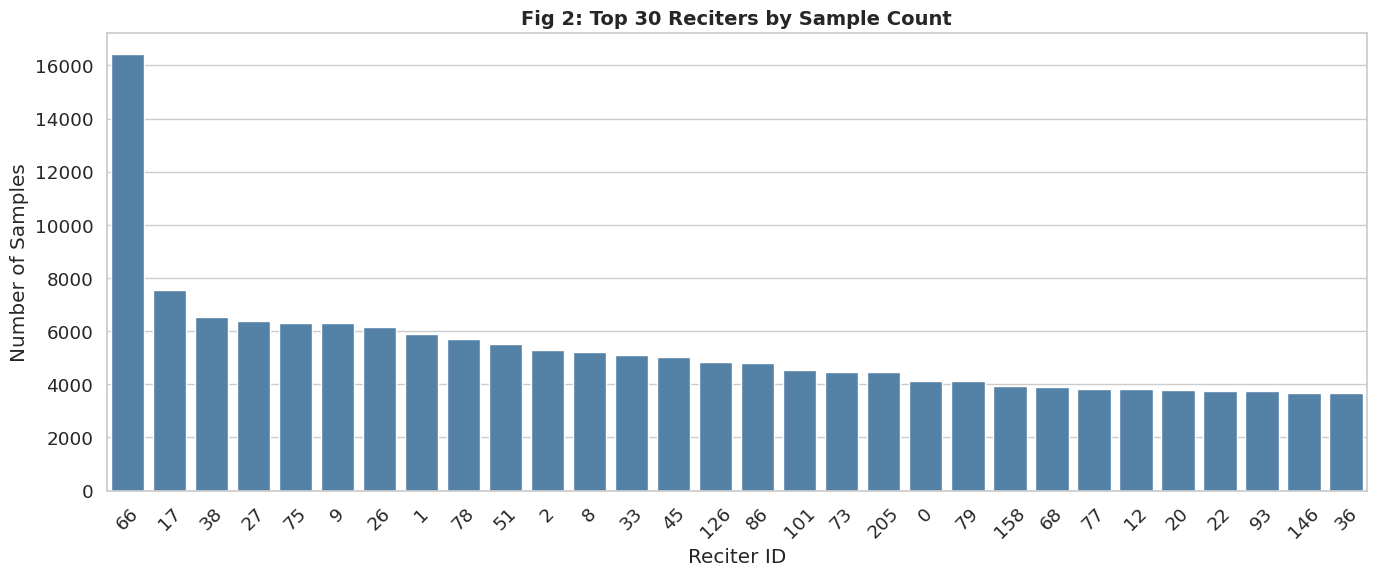

Top 5 most recorded reciters:
reciter_id
66    16415
17     7544
38     6544
27     6398
75     6325
Name: count, dtype: int64


In [18]:
top_reciters = df["reciter_id"].value_counts().head(30)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_reciters.index.astype(str), y=top_reciters.values, color="steelblue")
plt.title("Fig 2: Top 30 Reciters by Sample Count", fontsize=14, fontweight="bold")
plt.xlabel("Reciter ID")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
SAVE("02_reciter_distribution")
plt.show()

print(f"Top 5 most recorded reciters:\n{top_reciters.head()}")

### 7.3 Surah Distribution

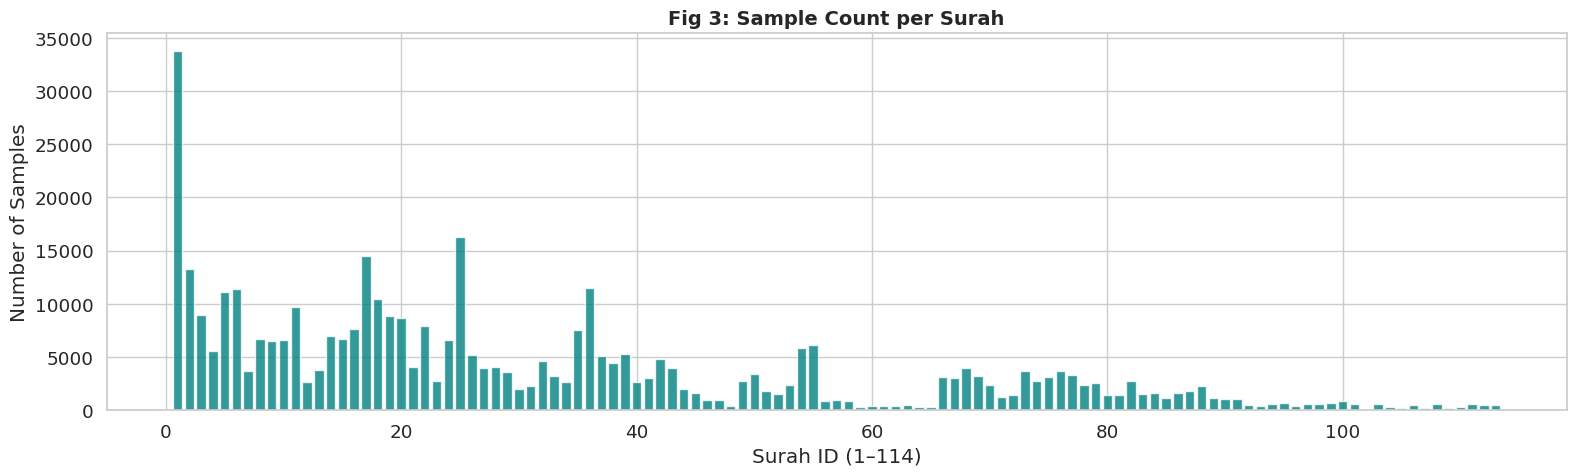

In [19]:
surah_counts = df["surah_id"].value_counts().sort_index()

plt.figure(figsize=(16, 5))
plt.bar(surah_counts.index, surah_counts.values, color="teal", alpha=0.8)
plt.title("Fig 3: Sample Count per Surah", fontsize=14, fontweight="bold")
plt.xlabel("Surah ID (1–114)")
plt.ylabel("Number of Samples")
plt.tight_layout()
SAVE("03_surah_distribution")
plt.show()

In [22]:
import json

df["word_count"] = df["text_ar_simple"].fillna("").apply(lambda x: len(x.split()))

### 7.4 Word Count per Ayah

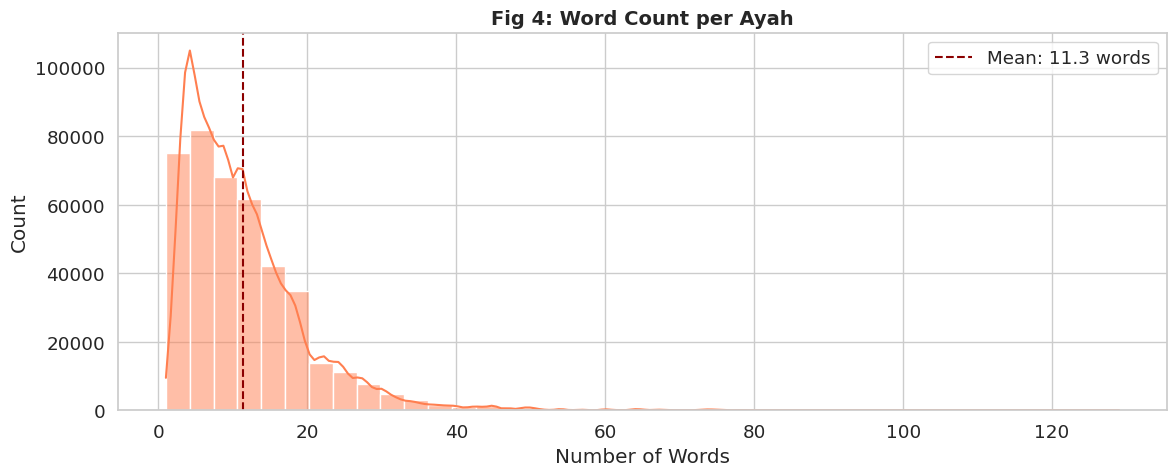

In [23]:
plt.figure(figsize=(12, 5))
sns.histplot(df["word_count"], bins=40, kde=True, color="coral")
plt.axvline(
    df["word_count"].mean(),
    color="darkred",
    linestyle="--",
    label=f'Mean: {df["word_count"].mean():.1f} words'
)
plt.title("Fig 4: Word Count per Ayah", fontsize=14, fontweight="bold")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### 7.5 Duration vs Word Count (Correlation)

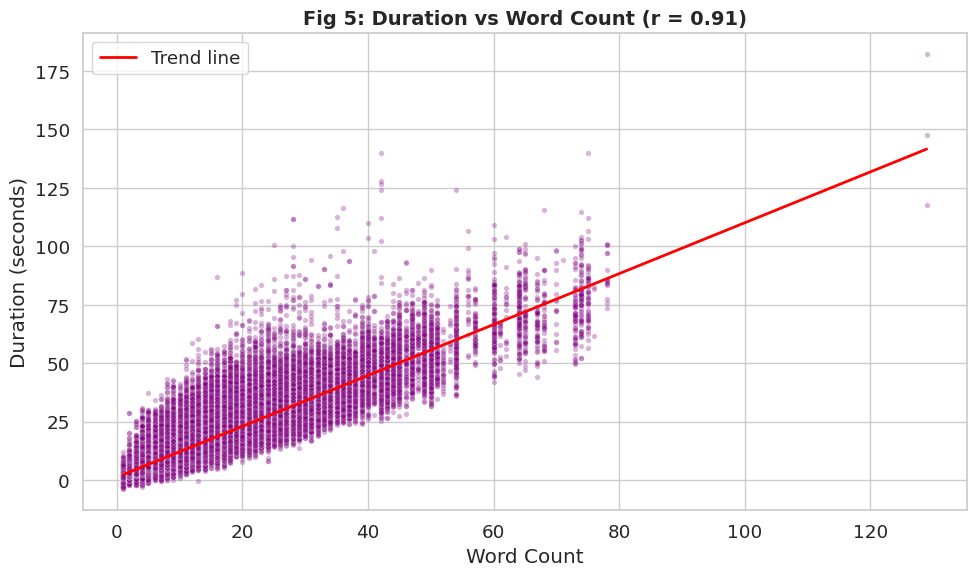

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="word_count", y="ayah_duration_s",
                alpha=0.3, color="purple", s=15)

import numpy as np
z = np.polyfit(df["word_count"], df["ayah_duration_s"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["word_count"].min(), df["word_count"].max(), 100)
plt.plot(x_line, p(x_line), color="red", linewidth=2, label="Trend line")

corr = df["word_count"].corr(df["ayah_duration_s"])
plt.title(f"Fig 5: Duration vs Word Count (r = {corr:.2f})", fontsize=14, fontweight="bold")
plt.xlabel("Word Count")
plt.ylabel("Duration (seconds)")
plt.legend()
plt.tight_layout()
plt.show()

### 7.6 Reciter Coverage Heatmap (Surah × Reciter)

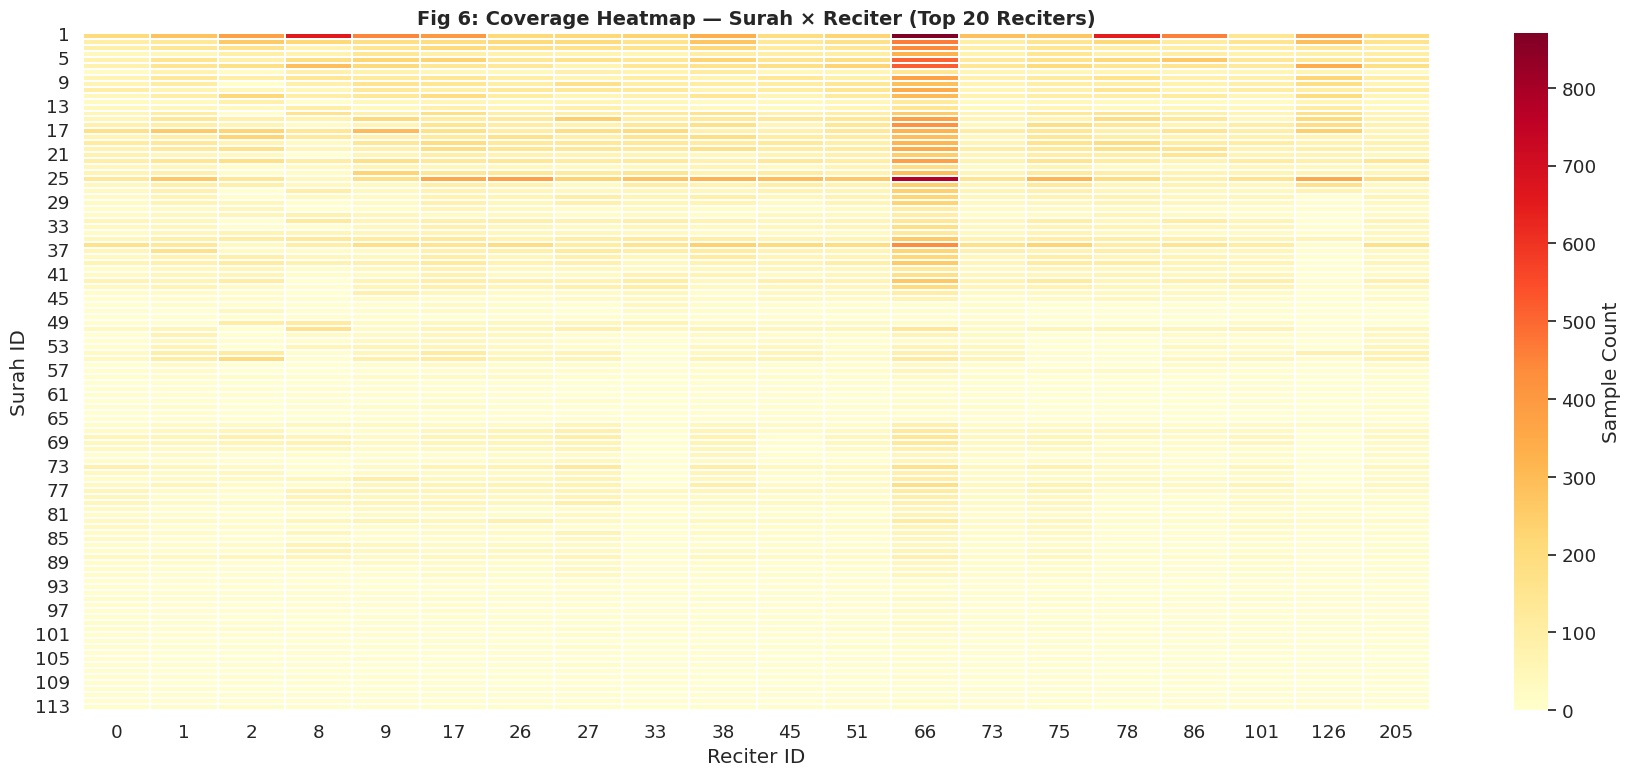

In [26]:
# Use top 20 reciters for readability
top20_reciters = df["reciter_id"].value_counts().head(20).index
df_top = df[df["reciter_id"].isin(top20_reciters)]

heatmap_data = df_top.groupby(["surah_id", "reciter_id"]).size().unstack(fill_value=0)

plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.1,
            cbar_kws={"label": "Sample Count"})
plt.title("Fig 6: Coverage Heatmap — Surah × Reciter (Top 20 Reciters)",
          fontsize=14, fontweight="bold")
plt.xlabel("Reciter ID")
plt.ylabel("Surah ID")
plt.tight_layout()
SAVE("06_coverage_heatmap")
plt.show()

### 7.7 Dataset Imbalance Analysis

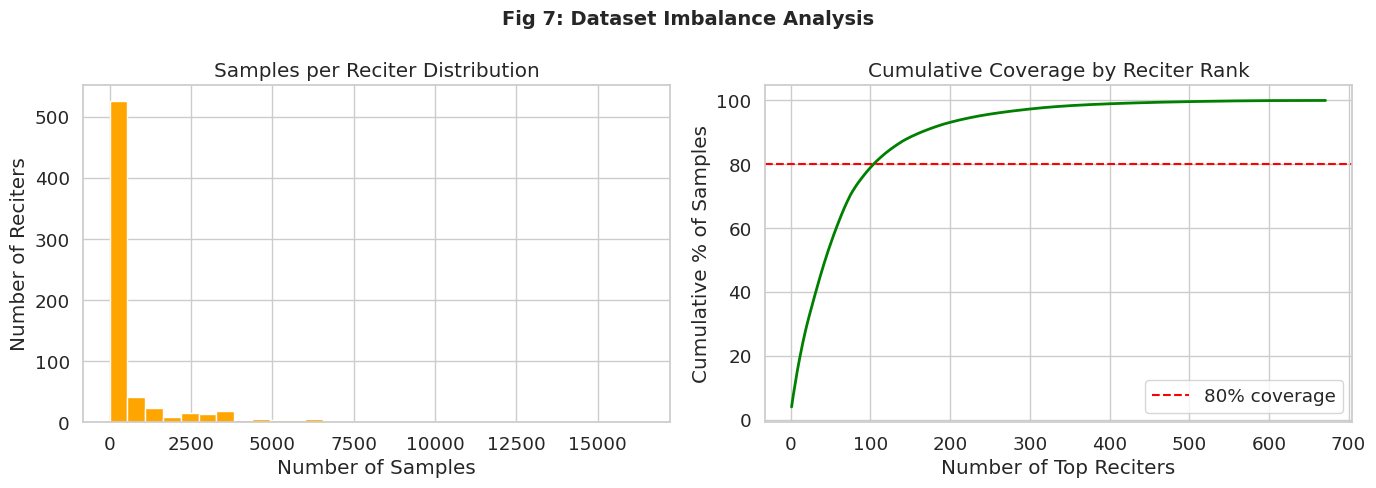

Top 104 reciters account for 80% of samples
Bottom 50% of reciters contribute only 1.9% of samples


In [27]:
reciter_counts = df["reciter_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of samples per reciter
axes[0].hist(reciter_counts.values, bins=30, color="orange", edgecolor="white")
axes[0].set_title("Samples per Reciter Distribution")
axes[0].set_xlabel("Number of Samples")
axes[0].set_ylabel("Number of Reciters")

# Cumulative coverage
sorted_counts = reciter_counts.sort_values(ascending=False)
cumsum = sorted_counts.cumsum() / sorted_counts.sum() * 100
axes[1].plot(range(1, len(cumsum)+1), cumsum.values, color="green", linewidth=2)
axes[1].axhline(80, color="red", linestyle="--", label="80% coverage")
axes[1].set_title("Cumulative Coverage by Reciter Rank")
axes[1].set_xlabel("Number of Top Reciters")
axes[1].set_ylabel("Cumulative % of Samples")
axes[1].legend()

plt.suptitle("Fig 7: Dataset Imbalance Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
SAVE("07_imbalance_analysis")
plt.show()

# How many reciters cover 80% of data?
n_for_80 = (cumsum < 80).sum() + 1
print(f"Top {n_for_80} reciters account for 80% of samples")
print(f"Bottom 50% of reciters contribute only {reciter_counts.tail(len(reciter_counts)//2).sum() / len(df) * 100:.1f}% of samples")

In [34]:
%pip install librosa soundfile


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 7.8 Play a Sample Audio

### 7.9 Waveform + Spectrogram Visualization

## 8. Save Statistics Summary

In [30]:
# Save the collected metadata for later use in training
df.to_csv("tadabur_eda_stats.csv", index=False)
print("Saved tadabur_eda_stats.csv")

# Print final summary for IEEE paper
print("\n=== SUMMARY FOR IEEE PAPER ===")
print(f"Dataset     : Tadabur (FaisaI/tadabur)")
print(f"Total rows  : 365,000+ samples (full dataset)")
print(f"Reciters    : 600+ unique reciters")
print(f"Surahs      : {df['surah_id'].nunique()} surahs in this sample")
print(f"Avg duration: {df['ayah_duration_s'].mean():.2f}s ± {df['ayah_duration_s'].std():.2f}s")
print(f"Avg words   : {df['word_count'].mean():.1f} words per ayah")
print(f"Sampling rate: 16,000 Hz (Whisper-compatible)")
print(f"Figures saved to: ./figures/")

Saved tadabur_eda_stats.csv

=== SUMMARY FOR IEEE PAPER ===
Dataset     : Tadabur (FaisaI/tadabur)
Total rows  : 365,000+ samples (full dataset)
Reciters    : 600+ unique reciters
Surahs      : 113 surahs in this sample
Avg duration: 13.51s ± 9.60s
Avg words   : 11.3 words per ayah
Sampling rate: 16,000 Hz (Whisper-compatible)
Figures saved to: ./figures/
